In [1]:
#Level 1 Task 1- Data Cleaning and Pre-processing 

In [2]:
#Import libraries 
import pandas as pd 
import numpy as np 

In [3]:
#Load dataset "iris", check how many rows and columns it contains, show the first five rows in the dataset.
df= pd.read_csv("iris.csv")

print ("Dataset loaded!")
print ("Shape:", df.shape)
df.head()

Dataset loaded!
Shape: (150, 5)


,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [4]:
#This shows what the dataset "iris" contains
print("Dataset Info")
df.info()

Dataset Info
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


In [5]:
 #This checks how many missing values are in each column of the dataset 
print("Missing Values")
print(df.isnull().sum())

Missing Values
sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
species         0
dtype: int64


In [6]:
#This checks if there are any duplicate in the dataset
print("Duplicates before cleaning:", df.duplicated().sum())

#Remove the duplicates 
df_clean = df.drop_duplicates()
df_clean = df_clean.reset_index(drop=True)

#Confirm that all duplicates are removed 
print("Duplicates after cleaning:", df_clean.duplicated().sum())
print("Rows removed:", len(df)- len(df_clean))
print("New Shape:", df_clean.shape)

Duplicates before cleaning: 3
Duplicates after cleaning: 0
Rows removed: 3
New Shape: (147, 5)


In [7]:
#Standardize Categorical Variables
#Species column are cleaned by removing extra spaces and making sure capitalizatioin is consistent

In [8]:
#Check species values before standarization 
print("Before standarization:")
print(df_clean["species"].value_counts())

#Remove spaces, make lowercase then capitalize first letter 
df_clean["species"] = df_clean["species"].str.strip().str.lower().str.capitalize()

#Confirmation 
print("\nAfter standarization")
print(df_clean["species"].value_counts())
      

Before standarization:
species
versicolor    50
virginica     49
setosa        48
Name: count, dtype: int64

After standarization
species
Versicolor    50
Virginica     49
Setosa        48
Name: count, dtype: int64


In [9]:
#Check for Outliners using IQR(Interquartile Range) method 
#Outliners are values that are unusually high or low, so we use IQR to find them.

In [10]:
numeric_cols = df_clean.select_dtypes(include=np.number).columns 

print("Outliers Detection")
for col in numeric_cols:
    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = df_clean[(df_clean[col] < lower) | (df_clean[col] > upper)]
    print(f"{col}: {len(outliers)} outlier(s) detected") 
    

Outliers Detection
sepal_length: 0 outlier(s) detected
sepal_width: 4 outlier(s) detected
petal_length: 0 outlier(s) detected
petal_width: 0 outlier(s) detected


In [11]:
#Final Dataset Summary
#A final check to confirm the dataset is fully cleaned 

In [12]:
print("===Final Dataset Summary===")
print(f"Final shape: {df_clean.shape}")
print(f"Missing values: {df_clean.isnull().sum().sum()}")
print(f"Duplicates: {df_clean.duplicated().sum()}")
print(df_clean.head())
print("\nLevel 1 Task 1 - Iris Dataset Cleaning Complete")

===Final Dataset Summary===
Final shape: (147, 5)
Missing values: 0
Duplicates: 0
   sepal_length  sepal_width  petal_length  petal_width species
0           5.1          3.5           1.4          0.2  Setosa
1           4.9          3.0           1.4          0.2  Setosa
2           4.7          3.2           1.3          0.2  Setosa
3           4.6          3.1           1.5          0.2  Setosa
4           5.0          3.6           1.4          0.2  Setosa

Level 1 Task 1 - Iris Dataset Cleaning Complete


In [13]:
# Save the cleaned dataset
df_clean.to_csv("iris_cleaned.csv", index=False)

print("Cleaned dataset saved successfully as 'iris_cleaned.csv'")

Cleaned dataset saved successfully as 'iris_cleaned.csv'


In [14]:
# Level 1 Task 2- Explanatory Data Analysis(EDA)

In [15]:
#Import Visualization Libraries(matplotlib and seaborn)
import matplotlib.pyplot as plt
import seaborn as sns 

In [16]:
#Summary statistics 
#We calculate mean, median, mode and standard deviation of each numerical colum in the dataset. 

In [17]:
#Display overall summary statistics 
print("Summary Statistics")
df_clean.describe()

Summary Statistics


,sepal_length,sepal_width,petal_length,petal_width
count,147.000000,147.000000,147.000000,147.000000
mean,5.856463,3.055782,3.780272,1.208844
std,0.829100,0.437009,1.759111,0.757874
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.400000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


In [18]:
#Calculate statistics for each numeric column 
for col in numeric_cols:
    print(f"\n{col}:")
    print(f" Mean:       {df_clean[col].mean():.4f}")
    print(f" Median:     {df_clean[col].median():.4f}")
    print(f" Mode:       {df_clean[col].mode()[0]:.4f}")
    print(f" Std Dev:    {df_clean[col].std():.4f}")


sepal_length:
 Mean:       5.8565
 Median:     5.8000
 Mode:       5.0000
 Std Dev:    0.8291

sepal_width:
 Mean:       3.0558
 Median:     3.0000
 Mode:       3.0000
 Std Dev:    0.4370

petal_length:
 Mean:       3.7803
 Median:     4.4000
 Mode:       1.4000
 Std Dev:    1.7591

petal_width:
 Mean:       1.2088
 Median:     1.3000
 Mode:       0.2000
 Std Dev:    0.7579


In [19]:
#Species Distribution(Count Plot)
#This chart shows how many flowers exist for each species.

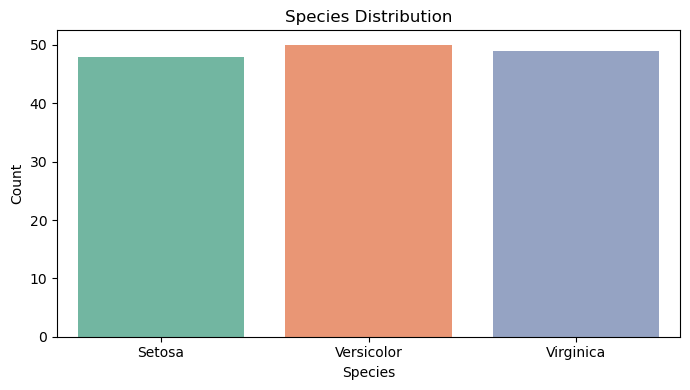

In [20]:
#Count plot showiing number of each species 
plt.figure(figsize=(7,4))
sns.countplot(data=df_clean, x="species", hue="species", palette="Set2", legend=False)
plt.title("Species Distribution")
plt.xlabel("Species")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

In [21]:
#Histograms
#Histograms show how values are distributed across each numeric column. Red line shows its mean

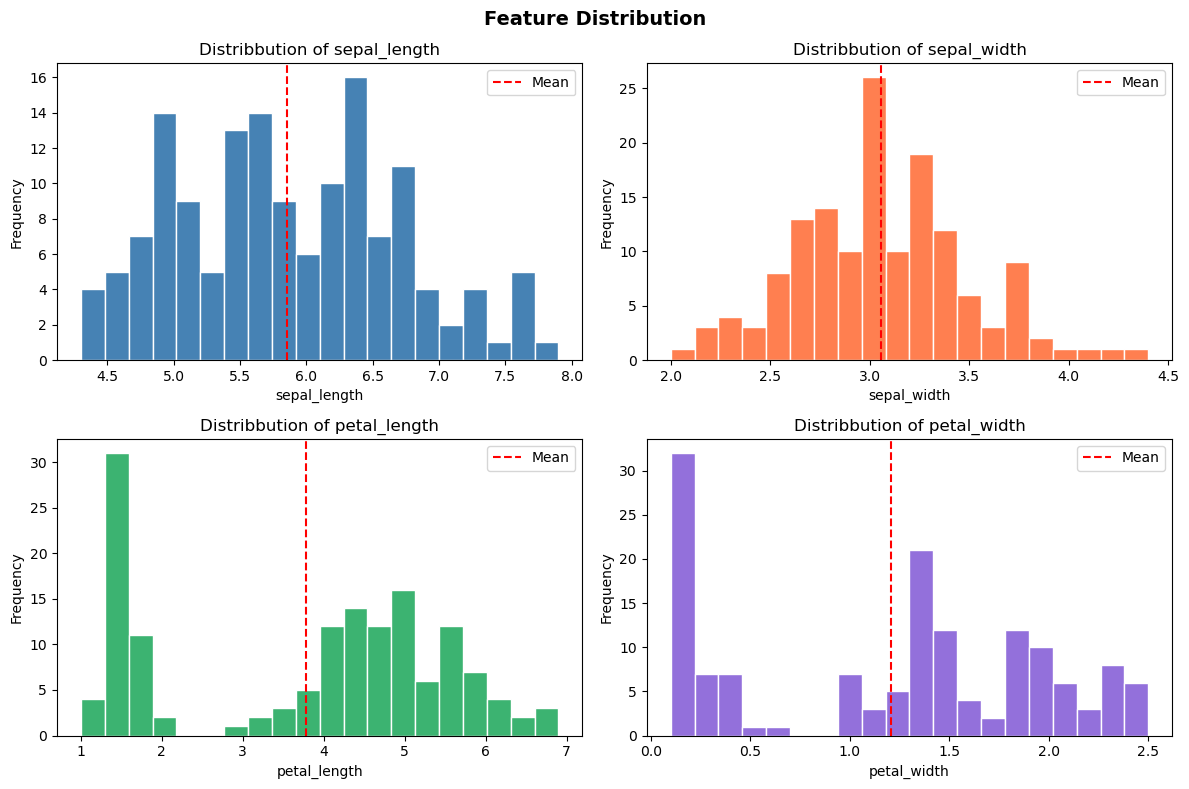

In [22]:
#Plot histogram for all 4 numeric column 
fig,axes = plt.subplots(2,2, figsize=(12,8))
axes = axes.flatten()

colors = ["steelblue", "coral", "mediumseagreen", "mediumpurple"]

for i, col in enumerate(numeric_cols):
    axes[i].hist(df_clean[col], bins = 20, color=colors[i], edgecolor="white")
    axes[i].set_title(f"Distribbution of {col}")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Frequency")
    axes[i].axvline(df_clean[col].mean(), color="red", linestyle="--", linewidth=1.5, label="Mean")
    axes[i].legend()

plt.suptitle("Feature Distribution", fontsize = 14, fontweight="bold")
plt.tight_layout()
plt.show()                       
                 

In [23]:
#Boxplots 
#Boxplots show the spread of data for each feature grouped by species. They also reveal outliners 

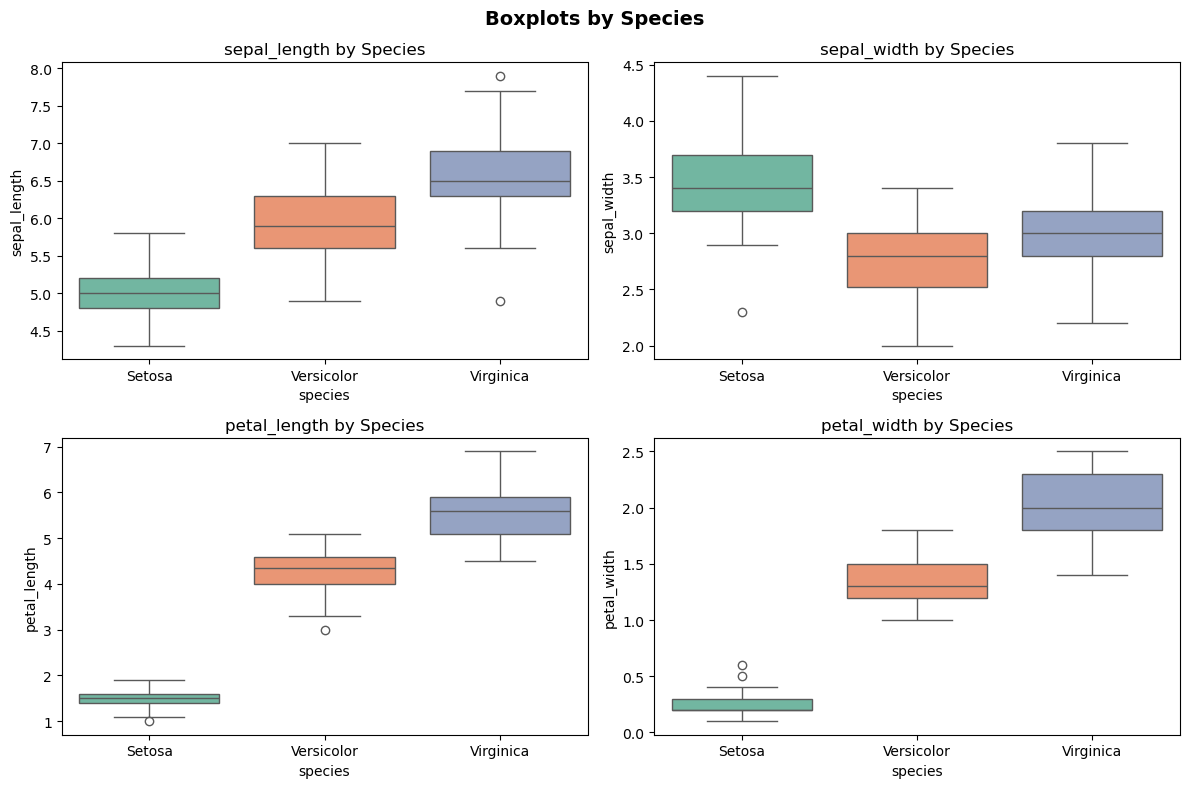

In [24]:
#Boxplots for each numeric column grouped by species 
fig, axes = plt.subplots(2,2, figsize=(12,8))
axes = axes.flatten()          
for i, col in enumerate(numeric_cols):
    sns.boxplot(data=df_clean, x="species", hue="species", y=col, palette="Set2", ax=axes[i], legend=False)
    axes[i].set_title(f"{col} by Species")
    axes[i].set_xlabel("species")
    axes[i].set_ylabel(col)

plt.suptitle("Boxplots by Species", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

In [25]:
#Scatter Plot
#It shows the relationship between two variables. Each dot represent one flower.

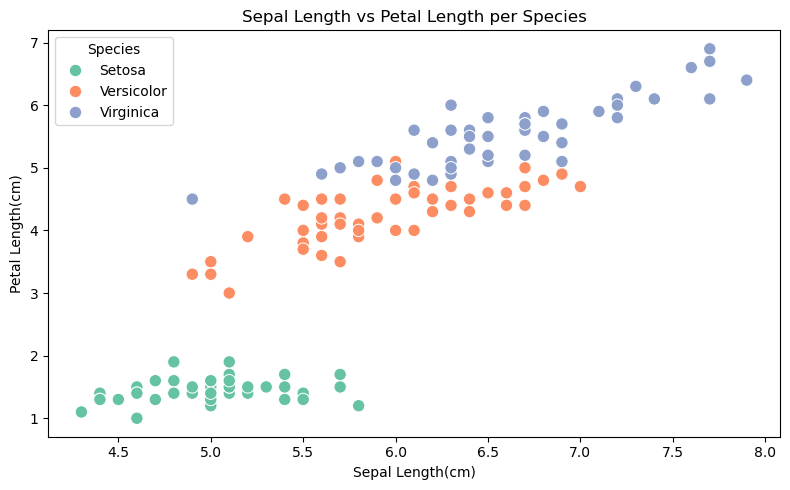

In [26]:
#Scatter plot of sepal_length vs petal_length 
plt.figure(figsize=(8,5))
sns.scatterplot(data=df_clean, x="sepal_length", y="petal_length", hue="species", palette="Set2", s=80)

plt.title("Sepal Length vs Petal Length per Species")
plt.xlabel("Sepal Length(cm)")
plt.ylabel("Petal Length(cm)")
plt.legend(title="Species")
plt.tight_layout()
plt.show()

In [27]:
#Correlation Heatmap
#A heatmap shows how strongly each faeture is realted to each other. Values close to 1 or -1 mean strrong correlation. Values close to 0 mean weak correlation.

Correlation Matrix
              sepal_length  sepal_width  petal_length  petal_width
sepal_length         1.000       -0.109         0.871        0.817
sepal_width         -0.109        1.000        -0.421       -0.356
petal_length         0.871       -0.421         1.000        0.962
petal_width          0.817       -0.356         0.962        1.000


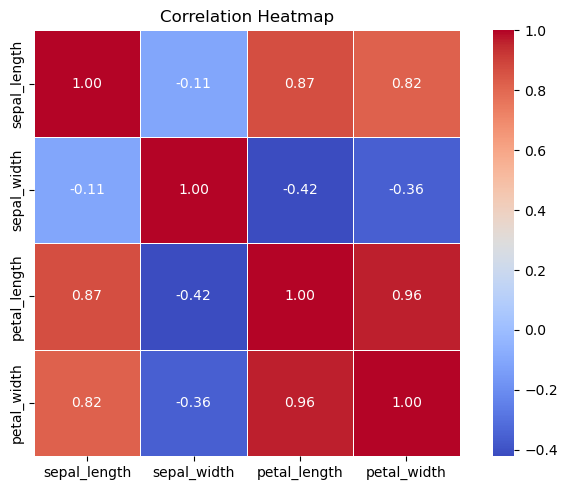

In [28]:
#Calculate correlation between all numeric columns 
corr_matrix =df_clean[numeric_cols].corr()

print("Correlation Matrix")
print(corr_matrix.round(3))

#Plot heatmap
plt.figure(figsize=(7,5))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", square=True, linewidth=0.5)
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

In [29]:
#Print key insights summary from analysis
print("="*50)
print(" Key Insights from EDA - Iris dataset")
print("="*50)
print(f"\n Total samples: {df_clean.shape[0]}")
print(f" Total features: {df_clean.shape[1]}")
print(f" Species: {list(df_clean["species"].unique())}")
print(f"\n Largest mean: sepal_length ={df_clean["sepal_length"].mean():.3f}cm")
print(f" Smallest mean: petal_width = {df_clean["petal_width"].mean():.3f}cm")
print(f" Most variable feature: petal_length(std= {df_clean["petal_length"].std():.3f})")
print("\n Strongest correlation: petal_length & petal_width")
print("\n Level 1 Task 2 - EDA on Iris Dataset Complete!")
print("="*50)

 Key Insights from EDA - Iris dataset

 Total samples: 147
 Total features: 5
 Species: ['Setosa', 'Versicolor', 'Virginica']

 Largest mean: sepal_length =5.856cm
 Smallest mean: petal_width = 1.209cm
 Most variable feature: petal_length(std= 1.759)

 Strongest correlation: petal_length & petal_width

 Level 1 Task 2 - EDA on Iris Dataset Complete!


In [30]:
#Level 2 Task 1- Regression Analysis 

In [31]:
#import regression libraries
from sklearn.model_selection import train_test_split 
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [32]:
#Prepare Data for Regression 
#We select sepal_lenght as our input (X) and petal_lenght as our output(y) to predict.

In [33]:
#Select input feature (X) and target variable (y)
X = df_clean[["sepal_length"]]  # input - double brackets makes it a table 
y = df_clean["petal_length"]    # input - single brackets makes it a column 

print("Input (X) shape:", X.shape)
print("Output (y) shape:", y.shape)
print("\nFirst 5 values of X:")
print(X.head())
print("\nFirst 5 values of y:")
print(y.head())

Input (X) shape: (147, 1)
Output (y) shape: (147,)

First 5 values of X:
   sepal_length
0           5.1
1           4.9
2           4.7
3           4.6
4           5.0

First 5 values of y:
0    1.4
1    1.4
2    1.3
3    1.5
4    1.4
Name: petal_length, dtype: float64


In [34]:
#Spilt Data into Training and Testing Dataset
#We spilt the data 80% for training and 20% for testing. Training data teaches the model, testing data checks it

In [35]:
#Spilt Data - 80% train, 20% test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Training size:", X_train.shape[0])
print("Testing size:", X_test.shape[0])
print("\n80% used to train, 20% used to test!")

Training size: 117
Testing size: 30

80% used to train, 20% used to test!


In [36]:
#Train the Linear Regression Model 
#We fit the model on our training data so it can learn the relationship between sepal and petal length

In [37]:
#Create and train the model 
model = LinearRegression()
model.fit(X_train, y_train)

print(f"Coefficient: {model.coef_[0]:.4f}")
print(f"Intercept: {model.intercept_:.4f}")

Coefficient: 1.8859
Intercept: -7.3097


In [38]:
#Use the model to make predictions on test data 
y_pred = model.predict(X_test)

print("Predictions vs Actual values:")
for i in range(5):
    print(f" Predicted: {y_pred[i]:.2f} | Actual: {y_test.values[i]:.2f}")

Predictions vs Actual values:
 Predicted: 4.19 | Actual: 4.90
 Predicted: 3.06 | Actual: 4.00
 Predicted: 5.33 | Actual: 5.60
 Predicted: 2.31 | Actual: 1.50
 Predicted: 1.93 | Actual: 4.50


In [39]:
#Evaluate model
#Calculate evaluation metrics 
r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)

print("Model Evaluation")
print(f"R-squared: {r2:.4f}")
print(f"Mean Squared Error {mse:.4f}")

if r2 >= 0.7:
   print("\nGood model performance!")
else:
   print("\nPoor model performance!")

Model Evaluation
R-squared: 0.7083
Mean Squared Error 0.8538

Good model performance!


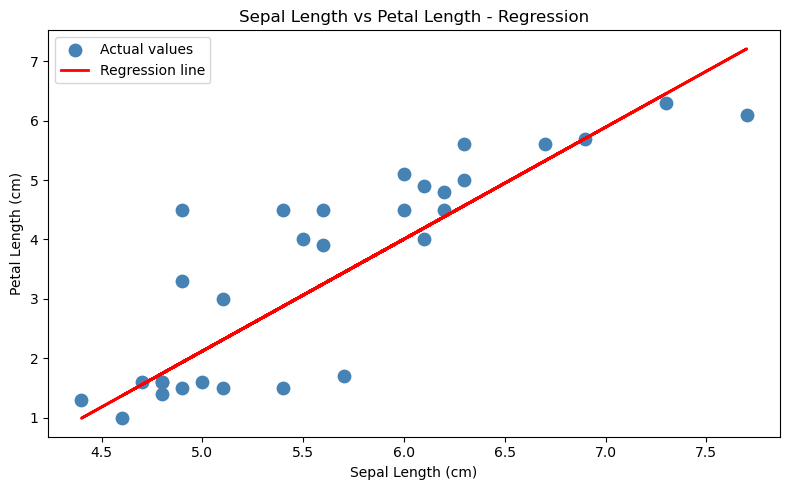

In [40]:
#Visualize the Regression line 
#Plot actual values on regression line
plt.figure(figsize= (8,5))
plt.scatter(X_test, y_test, color="steelblue", label="Actual values", s=80)
plt.plot(X_test, y_pred, color="red", linewidth=2, label="Regression line")
plt.title("Sepal Length vs Petal Length - Regression")
plt.xlabel("Sepal Length (cm)")
plt.ylabel("Petal Length (cm)")
plt.legend()
plt.tight_layout()
plt.show()

In [41]:
#Regression Analysis Summary 
print("="*50)
print("  REGRESSION ANALYSIS SUMMARY")
print("="*50)
print(f"\n Training samples: {X_train.shape[0]}")
print(f" Testing samples: {X_test.shape[0]}")
print(f" Coefficient: {model.coef_[0]}")
print(f" Intercept: {model.intercept_:.4f}")
print(f" R-squared: {r2:.4f}")
print(f" MSE: {mse:.4f}")
print("\nLevel 2 Task 1- Regression Analysis Completed")
print("="*50)

  REGRESSION ANALYSIS SUMMARY

 Training samples: 117
 Testing samples: 30
 Coefficient: 1.8858717393252724
 Intercept: -7.3097
 R-squared: 0.7083
 MSE: 0.8538

Level 2 Task 1- Regression Analysis Completed


In [42]:
#Level 2 Task 3- Clustering Analysis(K-Means)

In [43]:
#import libraries 
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler 
import warnings
warnings.filterwarnings("ignore")

In [44]:
#Select Features for Clustering
#Select all numeric columns for clustering 
X_cluster = df_clean[["sepal_length", "sepal_width", "petal_length", "petal_width"]]

print("Features selected:", list(X_cluster.columns))
print("Shape:", X_cluster.shape)

Features selected: ['sepal_length', 'sepal_width', 'petal_length', 'petal_width']
Shape: (147, 4)


In [45]:
#Standardize the Data 
# Standardizing puts all faetures on the same scale so no single feature dominates the clustering

In [46]:
#Standardize the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cluster)

print("First row before scaling:", X_cluster.values[0])
print("First row after scaling:", X_scaled[0].round(3))

First row before scaling: [5.1 3.5 1.4 0.2]
First row after scaling: [-0.916  1.02  -1.358 -1.336]


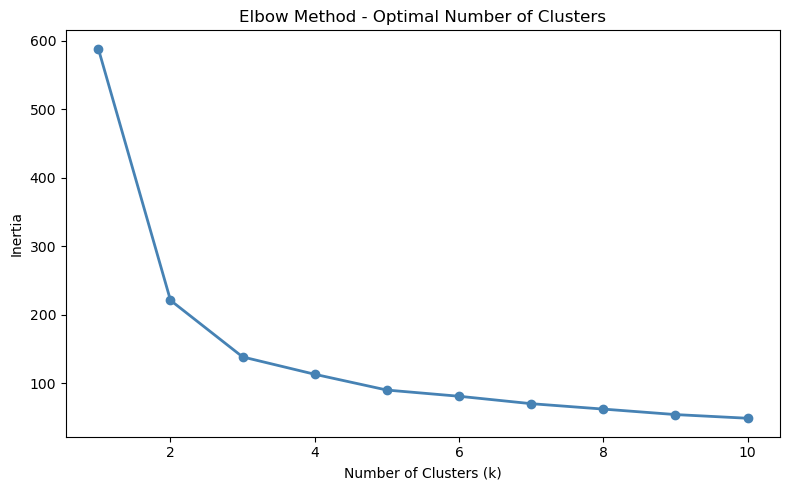

In [47]:
#Find Optimal Number of Clusters (Elbow Method)
#Test k values from 1 to 10
inertia = []
k_range = range(1, 11)

for k in k_range: 
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

#Plot the elbow curve
plt.figure(figsize=(8, 5))
plt.plot(k_range, inertia, marker="o", color="steelblue", linewidth=2)
plt.title("Elbow Method - Optimal Number of Clusters")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.tight_layout()
plt.show()

In [48]:
#Apply K-Means Clustering 
#Apply K-Means with k=3
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df_clean["cluster"] = kmeans.fit_predict(X_scaled)

print("Cluster counts:")
print(df_clean["cluster"].value_counts())

Cluster counts:
cluster
0    52
1    48
2    47
Name: count, dtype: int64


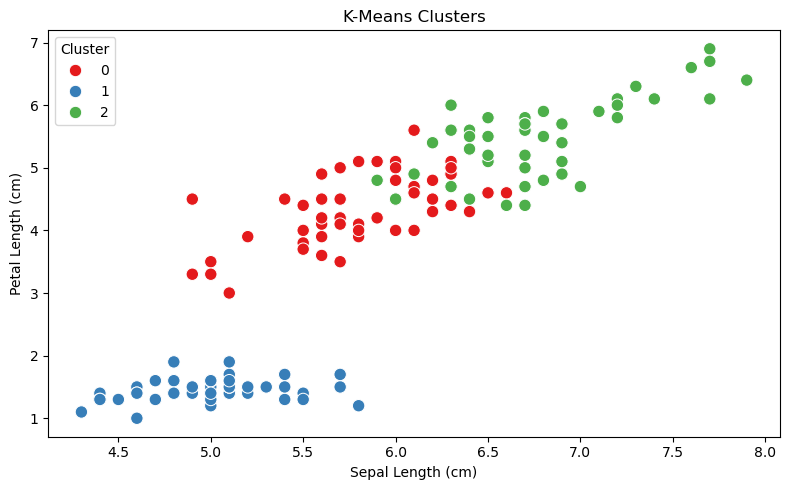

In [49]:
#Visualize Clusters 
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df_clean, x="sepal_length", y="petal_length", hue="cluster", palette="Set1", s=80)
plt.title("K-Means Clusters")
plt.xlabel("Sepal Length (cm)")
plt.ylabel("Petal Length (cm)")
plt.legend(title="Cluster")
plt.tight_layout()
plt.show()

In [50]:
#Clustering Analysis Summary 
print("="*50)
print("  K-MEANS CLUSTERING SUMMARY")
print("="*50)
print(f"\n Total samples clustered: {df_clean.shape[0]}")
print(f" Number of clusters: 3")
print(f"\n Cluster dfistribution:")
for i in range(3):
    count = (df_clean["cluster"] == i).sum()
    print(f" Cluster {i}: {count} flowers")
print("\nLevel 2 Task 3- Cluistering Analysis Completed")
print("="*50)

  K-MEANS CLUSTERING SUMMARY

 Total samples clustered: 147
 Number of clusters: 3

 Cluster dfistribution:
 Cluster 0: 52 flowers
 Cluster 1: 48 flowers
 Cluster 2: 47 flowers

Level 2 Task 3- Cluistering Analysis Completed


In [51]:
#Level 3 Task 1- Predicting Modeling(Classification)

In [52]:
#import libaries 
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import LabelEncoder

In [53]:
#Prepare Data for Classification.X is all 4 numeric features, y is the species column.We encode species as numbers for the model.
# Select features and target
X_clf = df_clean[['sepal_length', 'sepal_width',
                   'petal_length', 'petal_width']]

# Encode species as numbers
le = LabelEncoder()
y_clf = le.fit_transform(df_clean['species'])

print("Classes:", list(le.classes_))
print("X shape:", X_clf.shape)
print("y shape:", y_clf.shape)

Classes: ['Setosa', 'Versicolor', 'Virginica']
X shape: (147, 4)
y shape: (147,)


In [54]:
#Split into Training and Testing Sets
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_clf, y_clf, test_size=0.2, random_state=42)

print("Training samples:", X_train_c.shape[0])
print("Testing samples:", X_test_c.shape[0])

Training samples: 117
Testing samples: 30


In [55]:
#Decision Tree Classifier
# Train Decision Tree
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train_c, y_train_c)
dt_pred = dt_model.predict(X_test_c)

dt_acc = accuracy_score(y_test_c, dt_pred)
print(f"Decision Tree Accuracy: {dt_acc:.4f}")

Decision Tree Accuracy: 0.9333


In [56]:
#Logistic Regression Classifier
# Train Logistic Regression
lr_model = LogisticRegression(max_iter=200, random_state=42)
lr_model.fit(X_train_c, y_train_c)
lr_pred = lr_model.predict(X_test_c)

lr_acc = accuracy_score(y_test_c, lr_pred)
print(f"Logistic Regression Accuracy: {lr_acc:.4f}")

Logistic Regression Accuracy: 0.9333


In [57]:
#Random Forest Classifier
# Train Random Forest
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train_c, y_train_c)
rf_pred = rf_model.predict(X_test_c)

rf_acc = accuracy_score(y_test_c, rf_pred)
print(f"Random Forest Accuracy: {rf_acc:.4f}")

Random Forest Accuracy: 0.9333


In [58]:
# Compare all models
models = ['Decision Tree', 'Logistic Regression', 'Random Forest']
predictions = [dt_pred, lr_pred, rf_pred]

print("="*60)
print(f"{'Model':<22} {'Accuracy':>9} {'Precision':>10} {'Recall':>8} {'F1':>6}")
print("="*60)

for name, pred in zip(models, predictions):
    acc = accuracy_score(y_test_c, pred)
    pre = precision_score(y_test_c, pred, average='weighted')
    rec = recall_score(y_test_c, pred, average='weighted')
    f1 = f1_score(y_test_c, pred, average='weighted')
    print(f"{name:<22} {acc:>9.4f} {pre:>10.4f} {rec:>8.4f} {f1:>6.4f}")

print("="*60)


Model                   Accuracy  Precision   Recall     F1
Decision Tree             0.9333     0.9333   0.9333 0.9333
Logistic Regression       0.9333     0.9333   0.9333 0.9333
Random Forest             0.9333     0.9333   0.9333 0.9333


In [59]:
#Hyperparameter Tuning with Grid Search
# Grid search for best Random Forest parameters
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [3, 5, None]
}

grid_search = GridSearchCV(RandomForestClassifier(random_state=42),
                           param_grid, cv=5, scoring='accuracy')
grid_search.fit(X_train_c, y_train_c)

print("Best parameters:", grid_search.best_params_)
print(f"Best accuracy:   {grid_search.best_score_:.4f}")

Best parameters: {'max_depth': 3, 'n_estimators': 50}
Best accuracy:   0.9659


In [60]:
#Key findings from our classification analysis.
print("="*50)
print("   CLASSIFICATION SUMMARY")
print("="*50)
print(f"\n Training samples: {X_train_c.shape[0]}")
print(f" Testing samples:  {X_test_c.shape[0]}")
print(f" Classes: {list(le.classes_)}")
print(f"\n Model Accuracies:")
print(f"   Decision Tree:       {dt_acc:.4f}")
print(f"   Logistic Regression: {lr_acc:.4f}")
print(f"   Random Forest:       {rf_acc:.4f}")
print(f"\n Best parameters: {grid_search.best_params_}")
print(f" Best tuned accuracy: {grid_search.best_score_:.4f}")
print("\nLevel 3Task 1 - Classification Complete!")
print("="*50)

   CLASSIFICATION SUMMARY

 Training samples: 117
 Testing samples:  30
 Classes: ['Setosa', 'Versicolor', 'Virginica']

 Model Accuracies:
   Decision Tree:       0.9333
   Logistic Regression: 0.9333
   Random Forest:       0.9333

 Best parameters: {'max_depth': 3, 'n_estimators': 50}
 Best tuned accuracy: 0.9659

Level 3Task 1 - Classification Complete!
